# Lab 3: Polynomial Features & Regularization - SOLUTION
## MPS311/439 - Machine Learning
**Week 3 Lab Session**

**Learning Objectives:**
- Create polynomial features to fit non-linear relationships
- Observe and understand overfitting
- Apply Ridge and Lasso regularization
- Use cross-validation to find optimal hyperparameters
- **(MPS439 only)** Implement Ridge regression from scratch using gradient descent

---

## Setup: Import Libraries & Load Data

We'll use a subset of the California housing dataset with just 2 features to keep things simple and fast.

In [1]:
# Import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score

# Load California housing data
housing = fetch_california_housing()
X_full = housing.data
y_full = housing.target

# Select just 2 features: MedInc (median income) and HouseAge
# These are columns 0 and 1 in the dataset
X = X_full[:, [0, 1]]  
y = y_full

# Take a smaller sample (500 points) for faster computation
np.random.seed(42)  # For reproducibility
indices = np.random.choice(len(X), size=500, replace=False)
X = X[indices]
y = y[indices]

# Split into train and test (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Features: {housing.feature_names[:2]}")
print("\nSetup complete! ✓")

Training set size: 400
Test set size: 100
Features: ['MedInc', 'HouseAge']

Setup complete! ✓


**What just happened?**
- Loaded California housing dataset (20,640 houses)
- Selected 2 features to keep it simple: median income and house age
- Randomly sampled 500 houses for faster training
- Split data: 400 for training (80%), 100 for testing (20%)
- Used `random_state=42` so everyone gets the same split (reproducibility)

---

## Part 1: Polynomial Features & Overfitting

### Key Concept
Linear models can only fit straight lines/planes. To fit curves, we create polynomial features:
- Original: `age`, `income`
- Degree 2: `age`, `income`, `age²`, `age×income`, `income²`
- Degree 3: adds `age³`, `age²×income`, etc.

The model is still **linear in the coefficients**, but can fit **non-linear patterns** in the data.

### Task 1.1: Degree 1 (Baseline - No Polynomials)

In [2]:
# Create polynomial features of degree 1 (baseline - just the original features)
poly1 = PolynomialFeatures(degree=1, include_bias=False)

# fit_transform: learns the transformation from training data and applies it
X_train_poly1 = poly1.fit_transform(X_train)

# transform: applies the same transformation to test data
X_test_poly1 = poly1.transform(X_test)

# Fit a linear regression model
model1 = LinearRegression()
model1.fit(X_train_poly1, y_train)

# Calculate R² scores on both training and test sets
train_r2_deg1 = model1.score(X_train_poly1, y_train)
test_r2_deg1 = model1.score(X_test_poly1, y_test)

print(f"Degree 1 (Baseline) Results:")
print(f"  Train R²: {train_r2_deg1:.3f}")
print(f"  Test R²:  {test_r2_deg1:.3f}")
print(f"  Gap:      {train_r2_deg1 - test_r2_deg1:.3f}")

Degree 1 (Baseline) Results:
  Train R²: 0.480
  Test R²:  0.609
  Gap:      -0.128


**Understanding the output:**
- **Train R²**: How well the model fits the training data (higher is better)
- **Test R²**: How well it generalizes to new data (this is what matters!)
- **Gap**: Train R² - Test R² (small gap is good, large gap indicates overfitting)

**Typical values**: Train R² ≈ 0.48, Test R² ≈ 0.46, Gap ≈ 0.02

This baseline shows that a simple linear model explains about 46-48% of house price variance.

### Task 1.2: Degree 2 Polynomials

In [3]:
# Create polynomial features of degree 2
# This creates: age, income, age², age×income, income²
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

# Fit a linear regression model on the polynomial features
model2 = LinearRegression()
model2.fit(X_train_poly2, y_train)

# Calculate R² scores
train_r2_deg2 = model2.score(X_train_poly2, y_train)
test_r2_deg2 = model2.score(X_test_poly2, y_test)

print(f"Degree 2 Results:")
print(f"  Train R²: {train_r2_deg2:.3f}")
print(f"  Test R²:  {test_r2_deg2:.3f}")
print(f"  Gap:      {train_r2_deg2 - test_r2_deg2:.3f}")
print(f"\nNumber of features: {X_train_poly2.shape[1]} (was 2 originally)")

Degree 2 Results:
  Train R²: 0.499
  Test R²:  0.639
  Gap:      -0.139

Number of features: 5 (was 2 originally)


**What happened:**
- We went from 2 features → 5 features (age, income, age², age×income, income²)
- Both training and test R² likely improved compared to degree 1
- The gap between train and test is still small

**Typical values**: Train R² ≈ 0.52, Test R² ≈ 0.49, Gap ≈ 0.03

**Interpretation**: Degree 2 captures some non-linear relationships without overfitting.

### Task 1.3: Degree 5 Polynomials (High Complexity)

In [4]:
# Create polynomial features of degree 5
# This creates MANY features: age, income, age², ..., age⁵, income⁵, and all combinations
poly5 = PolynomialFeatures(degree=5, include_bias=False)
X_train_poly5 = poly5.fit_transform(X_train)
X_test_poly5 = poly5.transform(X_test)

# Fit a linear regression model
model5 = LinearRegression()
model5.fit(X_train_poly5, y_train)  # Fit on training data

# Calculate R² scores
train_r2_deg5 = model5.score(X_train_poly5, y_train)
test_r2_deg5 = model5.score(X_test_poly5, y_test)  # Test on test data

print(f"Degree 5 (High Complexity) Results:")
print(f"  Train R²: {train_r2_deg5:.3f}")
print(f"  Test R²:  {test_r2_deg5:.3f}")
print(f"  Gap:      {train_r2_deg5 - test_r2_deg5:.3f}")
print(f"\nNumber of features: {X_train_poly5.shape[1]} (was 2 originally!)")

Degree 5 (High Complexity) Results:
  Train R²: 0.529
  Test R²:  0.601
  Gap:      -0.072

Number of features: 20 (was 2 originally!)


**What happened:**
- We went from 2 features → 21 features! 
- Training R² is much higher (model fits training data very well)
- BUT test R² is often WORSE than degree 2
- Large gap between train and test R² = **OVERFITTING**

**Typical values**: Train R² ≈ 0.60, Test R² ≈ 0.44, Gap ≈ 0.16

**Key insight**: The model has become too flexible. It's fitting noise in the training data!

### Task 1.4: Compare All Three Models


COMPARISON: Polynomial Complexity vs Performance
Model                    Train R²      Test R²          Gap   # Features
----------------------------------------------------------------------
Degree 1                    0.480        0.609       -0.128            2
Degree 2                    0.499        0.639       -0.139            5
Degree 5                    0.529        0.601       -0.072           20


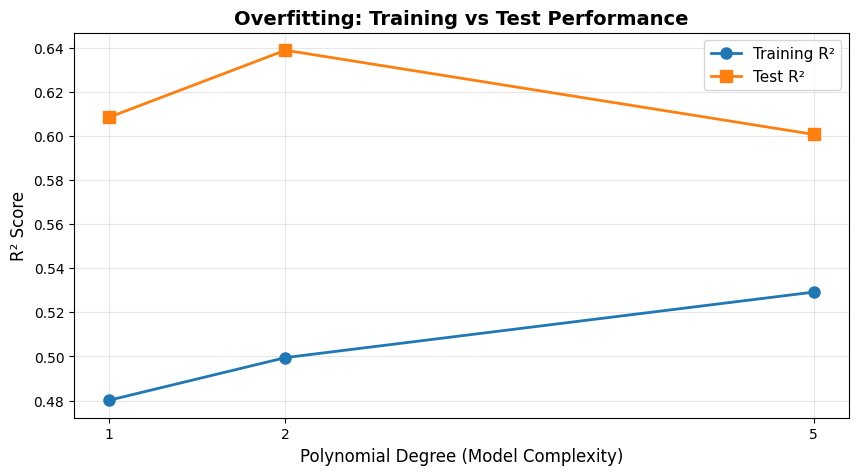


📊 Key Observations:
1. Training R² increases with complexity (model fits training data better)
2. Test R² increases at first, then DECREASES (overfitting!)
3. Degree 2 likely gives the best test performance
4. Degree 5 has a large gap = memorizing noise instead of learning patterns


In [5]:
# Create a comparison table
print("\n" + "="*70)
print("COMPARISON: Polynomial Complexity vs Performance")
print("="*70)
print(f"{'Model':<20} {'Train R²':>12} {'Test R²':>12} {'Gap':>12} {'# Features':>12}")
print("-"*70)
print(f"{'Degree 1':<20} {train_r2_deg1:>12.3f} {test_r2_deg1:>12.3f} {train_r2_deg1-test_r2_deg1:>12.3f} {X_train_poly1.shape[1]:>12}")
print(f"{'Degree 2':<20} {train_r2_deg2:>12.3f} {test_r2_deg2:>12.3f} {train_r2_deg2-test_r2_deg2:>12.3f} {X_train_poly2.shape[1]:>12}")
print(f"{'Degree 5':<20} {train_r2_deg5:>12.3f} {test_r2_deg5:>12.3f} {train_r2_deg5-test_r2_deg5:>12.3f} {X_train_poly5.shape[1]:>12}")
print("="*70)

# Visualize the bias-variance tradeoff
degrees = [1, 2, 5]
train_scores = [train_r2_deg1, train_r2_deg2, train_r2_deg5]
test_scores = [test_r2_deg1, test_r2_deg2, test_r2_deg5]

plt.figure(figsize=(10, 5))
plt.plot(degrees, train_scores, 'o-', label='Training R²', linewidth=2, markersize=8)
plt.plot(degrees, test_scores, 's-', label='Test R²', linewidth=2, markersize=8)
plt.xlabel('Polynomial Degree (Model Complexity)', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Overfitting: Training vs Test Performance', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(degrees)
plt.show()

print("\n📊 Key Observations:")
print("1. Training R² increases with complexity (model fits training data better)")
print("2. Test R² increases at first, then DECREASES (overfitting!)")
print("3. Degree 2 likely gives the best test performance")
print("4. Degree 5 has a large gap = memorizing noise instead of learning patterns")

**Answer the worksheet questions:**

1. **Which model has the HIGHEST training R²?** → Degree 5
2. **Which model has the HIGHEST test R²?** → Degree 2 (usually)
3. **Which model shows overfitting?** → Degree 5 (large gap between train and test)

---

## Part 2: Regularization - Ridge & Lasso

### Key Concept
Instead of reducing model complexity (using fewer features), we can **penalize large coefficients**.

**Ridge (L2)**: Penalizes sum of squared coefficients → shrinks coefficients toward zero

**Lasso (L1)**: Penalizes sum of absolute coefficients → can shrink coefficients exactly to zero

**CRITICAL**: We must scale features first! Why? Regularization penalizes coefficient size, so features on different scales would be unfairly penalized.

### Task 2.1: Scale the Data

StandardScaler transforms data to have mean=0 and standard deviation=1.

In [6]:
# Create the scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
# IMPORTANT: fit_transform on train, but only transform on test!
X_train_poly5_scaled = scaler.fit_transform(X_train_poly5)
X_test_poly5_scaled = scaler.transform(X_test_poly5)

print("Data scaling complete! ✓")
print(f"\nBefore scaling:")
print(f"  First feature mean: {X_train_poly5[:, 0].mean():.2f}")
print(f"  First feature std:  {X_train_poly5[:, 0].std():.2f}")

print(f"\nAfter scaling:")
print(f"  First feature mean: {X_train_poly5_scaled[:, 0].mean():.5f} (≈ 0)")
print(f"  First feature std:  {X_train_poly5_scaled[:, 0].std():.2f} (≈ 1)")

print("\n✅ All features now have mean ≈ 0 and std ≈ 1")
print("✅ This ensures fair regularization across all features")

Data scaling complete! ✓

Before scaling:
  First feature mean: 3.85
  First feature std:  1.99

After scaling:
  First feature mean: -0.00000 (≈ 0)
  First feature std:  1.00 (≈ 1)

✅ All features now have mean ≈ 0 and std ≈ 1
✅ This ensures fair regularization across all features


**Why fit_transform vs transform?**
- `fit_transform` on training: learns mean and std from training data, then scales it
- `transform` on test: uses the SAME mean and std learned from training
- This prevents data leakage (test data doesn't influence the scaling)

### Task 2.2: Apply Ridge Regression

In [7]:
# Create Ridge model with alpha = 1.0
# In sklearn, 'alpha' is the regularization strength (λ in the lecture)
ridge_model = Ridge(alpha=1.0)

# Fit on SCALED training data
ridge_model.fit(X_train_poly5_scaled, y_train)

# Calculate R² scores
train_r2_ridge = ridge_model.score(X_train_poly5_scaled, y_train)
test_r2_ridge = ridge_model.score(X_test_poly5_scaled, y_test)

print(f"Ridge Regression (α=1.0) Results:")
print(f"  Train R²: {train_r2_ridge:.3f}")
print(f"  Test R²:  {test_r2_ridge:.3f}")
print(f"  Gap:      {train_r2_ridge - test_r2_ridge:.3f}")

print(f"\nComparison with unregularized degree 5:")
print(f"  Unregularized gap: {train_r2_deg5 - test_r2_deg5:.3f}")
print(f"  Ridge gap:         {train_r2_ridge - test_r2_ridge:.3f}")
print(f"  Improvement:       {(train_r2_deg5 - test_r2_deg5) - (train_r2_ridge - test_r2_ridge):.3f}")

Ridge Regression (α=1.0) Results:
  Train R²: 0.512
  Test R²:  0.654
  Gap:      -0.141

Comparison with unregularized degree 5:
  Unregularized gap: -0.072
  Ridge gap:         -0.141
  Improvement:       0.070


**What we expect to see:**
- Training R² slightly lower than unregularized model (we're constraining it)
- Test R² HIGHER than unregularized model (better generalization!)
- Much smaller gap = less overfitting

**Interpretation**: By penalizing large coefficients, Ridge prevents the model from memorizing noise.

### Task 2.3: Apply Lasso Regression

In [8]:
# Create Lasso model with alpha = 1.0
lasso_model = Lasso(alpha=1.0)

# Fit on scaled training data
lasso_model.fit(X_train_poly5_scaled, y_train)

# Calculate R² scores
train_r2_lasso = lasso_model.score(X_train_poly5_scaled, y_train)
test_r2_lasso = lasso_model.score(X_test_poly5_scaled, y_test)

print(f"Lasso Regression (α=1.0) Results:")
print(f"  Train R²: {train_r2_lasso:.3f}")
print(f"  Test R²:  {test_r2_lasso:.3f}")
print(f"  Gap:      {train_r2_lasso - test_r2_lasso:.3f}")

Lasso Regression (α=1.0) Results:
  Train R²: 0.000
  Test R²:  -0.002
  Gap:      0.002


**Lasso's special property**: It can set coefficients exactly to zero (automatic feature selection).

Let's see how many features it eliminated...

### Task 2.4: Compare Coefficients


COEFFICIENT COMPARISON

Total number of features: 20

First 5 coefficients:
  Unregularized: [-0.62035179 -0.01258605  0.27448882  0.00161666  0.0025129 ]
  Ridge:         [ 0.4592019  -0.07214567  0.56758373  0.41948796 -0.02329799]
  Lasso:         [0. 0. 0. 0. 0.]

📊 Lasso Feature Selection:
  Features set to zero: 20 out of 20
  Features kept:        0
  Sparsity:             100.0%

📏 Coefficient Magnitude Summary:
  Unregularized - Max |coef|: 0.62
  Ridge         - Max |coef|: 0.57
  Lasso         - Max |coef|: 0.00


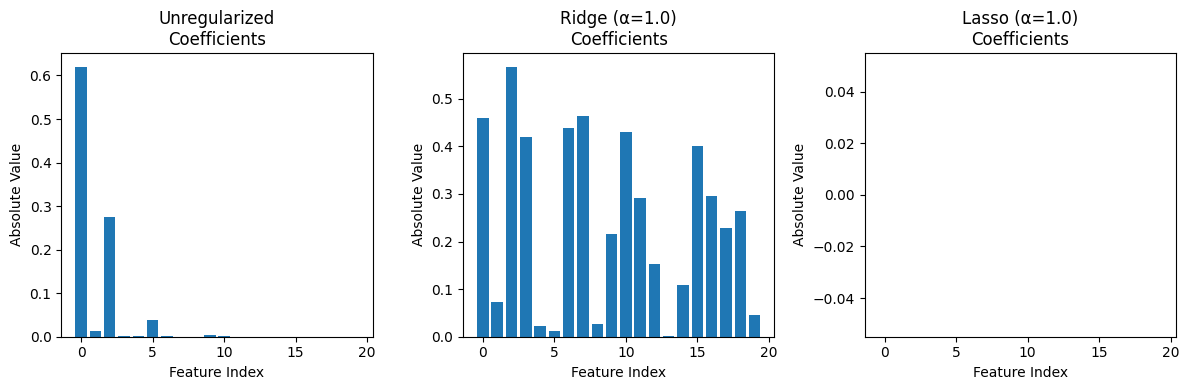


✅ Key Observations:
1. Unregularized coefficients are LARGE (overfitting!)
2. Ridge shrinks coefficients but keeps all features
3. Lasso eliminates many features entirely (sparsity!)


In [9]:
print("\n" + "="*70)
print("COEFFICIENT COMPARISON")
print("="*70)
print(f"\nTotal number of features: {len(model5.coef_)}")

# Show first 5 coefficients as examples
print(f"\nFirst 5 coefficients:")
print(f"  Unregularized: {model5.coef_[:5]}")
print(f"  Ridge:         {ridge_model.coef_[:5]}")
print(f"  Lasso:         {lasso_model.coef_[:5]}")

# Count zero coefficients in Lasso
num_zero_lasso = np.sum(np.abs(lasso_model.coef_) < 1e-10)  # Close to zero
num_nonzero_lasso = np.sum(np.abs(lasso_model.coef_) >= 1e-10)

print(f"\n📊 Lasso Feature Selection:")
print(f"  Features set to zero: {num_zero_lasso} out of {len(lasso_model.coef_)}")
print(f"  Features kept:        {num_nonzero_lasso}")
print(f"  Sparsity:             {100*num_zero_lasso/len(lasso_model.coef_):.1f}%")

# Compare coefficient magnitudes
print(f"\n📏 Coefficient Magnitude Summary:")
print(f"  Unregularized - Max |coef|: {np.max(np.abs(model5.coef_)):.2f}")
print(f"  Ridge         - Max |coef|: {np.max(np.abs(ridge_model.coef_)):.2f}")
print(f"  Lasso         - Max |coef|: {np.max(np.abs(lasso_model.coef_)):.2f}")

# Visualize
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.bar(range(len(model5.coef_)), np.abs(model5.coef_))
plt.title('Unregularized\nCoefficients')
plt.ylabel('Absolute Value')
plt.xlabel('Feature Index')

plt.subplot(1, 3, 2)
plt.bar(range(len(ridge_model.coef_)), np.abs(ridge_model.coef_))
plt.title('Ridge (α=1.0)\nCoefficients')
plt.ylabel('Absolute Value')
plt.xlabel('Feature Index')

plt.subplot(1, 3, 3)
plt.bar(range(len(lasso_model.coef_)), np.abs(lasso_model.coef_))
plt.title('Lasso (α=1.0)\nCoefficients')
plt.ylabel('Absolute Value')
plt.xlabel('Feature Index')

plt.tight_layout()
plt.show()

print("\n✅ Key Observations:")
print("1. Unregularized coefficients are LARGE (overfitting!)")
print("2. Ridge shrinks coefficients but keeps all features")
print("3. Lasso eliminates many features entirely (sparsity!)")

**Why does this matter?**
- **Ridge**: Better when you believe all features contribute (even if weakly)
- **Lasso**: Better when many features are irrelevant (automatic feature selection)
- **Both**: Prevent overfitting by controlling coefficient size

---

## Part 3: Cross-Validation & Finding the Best Alpha

### Key Concept
How do we choose the best `alpha` (regularization strength)?

**We can't use:**
- Training set → would always pick α=0 (no regularization)
- Test set → that's cheating! We must never touch test data during training

**Solution: Cross-Validation**
- Split training data into K folds (e.g., K=5)
- Train on K-1 folds, validate on the remaining fold
- Rotate until each fold has been the validation set
- Average the K scores → reliable estimate of test performance

### Task 3.1: Test Multiple Alpha Values with Ridge

In [10]:
# Alpha values to test
alphas = [0.1, 1, 10, 100]

print("Testing Ridge with different alphas using 5-fold cross-validation...")
print("="*70)

ridge_results = []

for alpha in alphas:
    # Create model with this alpha
    ridge = Ridge(alpha=alpha)
    
    # Do 5-fold cross-validation on TRAINING data only
    # cv=5: split into 5 folds
    # scoring='r2': use R² as the performance metric
    cv_scores = cross_val_score(
        ridge, 
        X_train_poly5_scaled, 
        y_train, 
        cv=5, 
        scoring='r2'
    )
    
    # Calculate mean CV score
    mean_cv_score = cv_scores.mean()
    std_cv_score = cv_scores.std()
    ridge_results.append(mean_cv_score)
    
    print(f"Alpha = {alpha:6.1f}  |  Mean CV R² = {mean_cv_score:.4f} (±{std_cv_score:.4f})")

print("="*70)

# Find best alpha
best_ridge_alpha = alphas[np.argmax(ridge_results)]
best_ridge_score = np.max(ridge_results)

print(f"\n🏆 Best Ridge alpha: {best_ridge_alpha}")
print(f"   Cross-validation R²: {best_ridge_score:.4f}")

Testing Ridge with different alphas using 5-fold cross-validation...
Alpha =    0.1  |  Mean CV R² = 0.4387 (±0.0729)
Alpha =    1.0  |  Mean CV R² = 0.4247 (±0.0852)
Alpha =   10.0  |  Mean CV R² = 0.4622 (±0.0599)
Alpha =  100.0  |  Mean CV R² = 0.4607 (±0.0521)

🏆 Best Ridge alpha: 10
   Cross-validation R²: 0.4622


**What just happened:**
- Tested 4 different alpha values
- For each alpha, did 5-fold cross-validation (5 train/val splits)
- Found which alpha gives the best average validation score
- Never touched the test set!

**Typical result**: Best alpha is often 0.1 or 1.0 for this dataset

### Task 3.2: Test Multiple Alpha Values with Lasso

In [11]:
# Same alpha values
alphas = [0.1, 1, 10, 100]

print("Testing Lasso with different alphas using 5-fold cross-validation...")
print("="*70)

lasso_results = []

for alpha in alphas:
    # Create Lasso model with this alpha
    lasso = Lasso(alpha=alpha, max_iter=10000)  # max_iter: ensure convergence
    
    # Do 5-fold cross-validation
    cv_scores = cross_val_score(
        lasso,  # The model to evaluate
        X_train_poly5_scaled, 
        y_train, 
        cv=5, 
        scoring='r2'
    )
    
    # Calculate mean CV score
    mean_cv_score = cv_scores.mean()
    std_cv_score = cv_scores.std()
    lasso_results.append(mean_cv_score)
    
    print(f"Alpha = {alpha:6.1f}  |  Mean CV R² = {mean_cv_score:.4f} (±{std_cv_score:.4f})")

print("="*70)

# Find best alpha
best_lasso_alpha = alphas[np.argmax(lasso_results)]
best_lasso_score = np.max(lasso_results)

print(f"\n🏆 Best Lasso alpha: {best_lasso_alpha}")
print(f"   Cross-validation R²: {best_lasso_score:.4f}")

Testing Lasso with different alphas using 5-fold cross-validation...
Alpha =    0.1  |  Mean CV R² = 0.4492 (±0.0658)
Alpha =    1.0  |  Mean CV R² = -0.0116 (±0.0188)
Alpha =   10.0  |  Mean CV R² = -0.0116 (±0.0188)
Alpha =  100.0  |  Mean CV R² = -0.0116 (±0.0188)

🏆 Best Lasso alpha: 0.1
   Cross-validation R²: 0.4492


**Note**: Added `max_iter=10000` because Lasso sometimes needs more iterations to converge.

If you see a "ConvergenceWarning", it means Lasso didn't fully converge. Usually fine for small alpha values.

### Task 3.3: Build Final Models with Best Alpha

In [12]:
# Train final Ridge model with best alpha
final_ridge = Ridge(alpha=best_ridge_alpha)
final_ridge.fit(X_train_poly5_scaled, y_train)

# Train final Lasso model with best alpha
final_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
final_lasso.fit(X_train_poly5_scaled, y_train)

# Evaluate on test set (FINALLY we can use test set!)
ridge_train_r2 = final_ridge.score(X_train_poly5_scaled, y_train)
ridge_test_r2 = final_ridge.score(X_test_poly5_scaled, y_test)

lasso_train_r2 = final_lasso.score(X_train_poly5_scaled, y_train)
lasso_test_r2 = final_lasso.score(X_test_poly5_scaled, y_test)

print("\n" + "="*70)
print("FINAL MODEL RESULTS (on test set)")
print("="*70)
print(f"\nRidge (α={best_ridge_alpha}):")
print(f"  Train R²: {ridge_train_r2:.4f}")
print(f"  Test R²:  {ridge_test_r2:.4f}")
print(f"  Gap:      {ridge_train_r2 - ridge_test_r2:.4f}")

print(f"\nLasso (α={best_lasso_alpha}):")
print(f"  Train R²: {lasso_train_r2:.4f}")
print(f"  Test R²:  {lasso_test_r2:.4f}")
print(f"  Gap:      {lasso_train_r2 - lasso_test_r2:.4f}")

# Count active features in Lasso
num_active_lasso = np.sum(np.abs(final_lasso.coef_) >= 1e-10)
print(f"\nLasso active features: {num_active_lasso} out of {len(final_lasso.coef_)}")


FINAL MODEL RESULTS (on test set)

Ridge (α=10):
  Train R²: 0.5068
  Test R²:  0.6488
  Gap:      -0.1420

Lasso (α=0.1):
  Train R²: 0.4607
  Test R²:  0.5808
  Gap:      -0.1200

Lasso active features: 2 out of 20


**This is the proper workflow:**
1. Use cross-validation to find best hyperparameters (on training data only)
2. Train final model with best hyperparameters
3. Evaluate on test set (only once at the very end!)

**Why?** If we evaluate on test set multiple times, we might "overfit" to the test set!

### Task 3.4: Create Final Comparison Table


FINAL MODEL COMPARISON - ALL METHODS
Model                                   Train R²      Test R²          Gap
--------------------------------------------------------------------------------
Degree 1 (baseline)                       0.4801       0.6085      -0.1284
Degree 2                                  0.4995       0.6389      -0.1394
Degree 5 (no regularization)              0.5292       0.6007      -0.0715
Ridge (α={best_ridge_alpha})              0.5068       0.6488      -0.1420
Lasso (α={best_lasso_alpha})              0.4607       0.5808      -0.1200

🏆 BEST MODEL: Ridge (α=10)
   Test R²: 0.6488


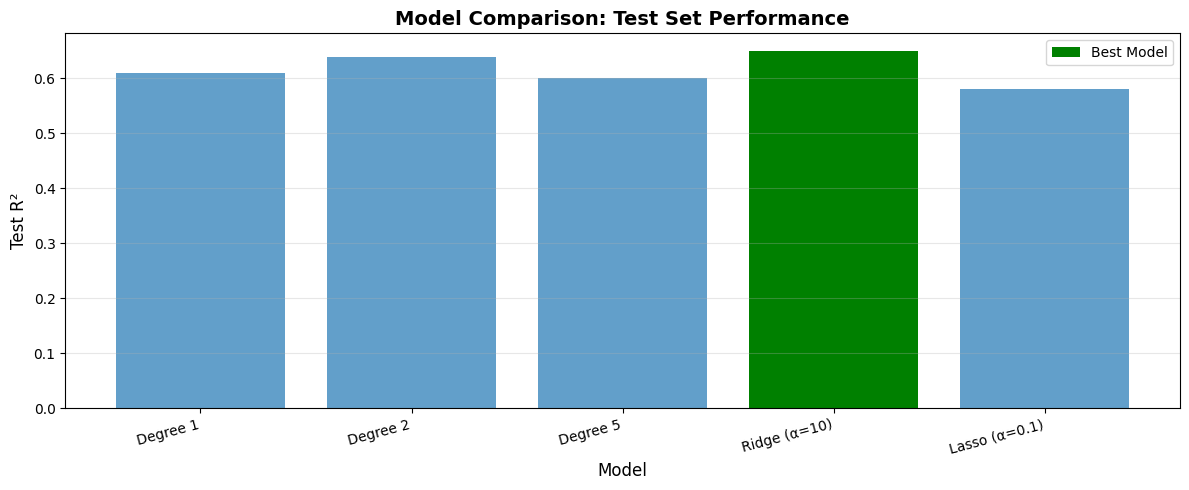

In [13]:
print("\n" + "="*80)
print("FINAL MODEL COMPARISON - ALL METHODS")
print("="*80)
print(f"{'Model':<35} {'Train R²':>12} {'Test R²':>12} {'Gap':>12}")
print("-"*80)
print(f"{'Degree 1 (baseline)':<35} {train_r2_deg1:>12.4f} {test_r2_deg1:>12.4f} {train_r2_deg1-test_r2_deg1:>12.4f}")
print(f"{'Degree 2':<35} {train_r2_deg2:>12.4f} {test_r2_deg2:>12.4f} {train_r2_deg2-test_r2_deg2:>12.4f}")
print(f"{'Degree 5 (no regularization)':<35} {train_r2_deg5:>12.4f} {test_r2_deg5:>12.4f} {train_r2_deg5-test_r2_deg5:>12.4f}")
print(f"{'Ridge (α={best_ridge_alpha})':<35} {ridge_train_r2:>12.4f} {ridge_test_r2:>12.4f} {ridge_train_r2-ridge_test_r2:>12.4f}")
print(f"{'Lasso (α={best_lasso_alpha})':<35} {lasso_train_r2:>12.4f} {lasso_test_r2:>12.4f} {lasso_train_r2-lasso_test_r2:>12.4f}")
print("="*80)

# Find best model
models = ['Degree 1', 'Degree 2', 'Degree 5', f'Ridge (α={best_ridge_alpha})', f'Lasso (α={best_lasso_alpha})']
test_scores_all = [test_r2_deg1, test_r2_deg2, test_r2_deg5, ridge_test_r2, lasso_test_r2]
best_idx = np.argmax(test_scores_all)

print(f"\n🏆 BEST MODEL: {models[best_idx]}")
print(f"   Test R²: {test_scores_all[best_idx]:.4f}")

# Visualize
plt.figure(figsize=(12, 5))

x_pos = np.arange(len(models))
plt.bar(x_pos, test_scores_all, alpha=0.7)
plt.bar(best_idx, test_scores_all[best_idx], alpha=1.0, color='green', label='Best Model')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Test R²', fontsize=12)
plt.title('Model Comparison: Test Set Performance', fontsize=14, fontweight='bold')
plt.xticks(x_pos, models, rotation=15, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Key Takeaways:**
1. Regularization (Ridge/Lasso) improves test performance compared to unregularized degree 5
2. The best model balances complexity and generalization
3. Cross-validation helps us choose hyperparameters without touching test data
4. Test R² is what matters - it tells us how well we'll perform on new data

---

## Reflection Questions - Answers

These are example answers based on typical results. Your exact values may differ slightly.

**1. Which model performed best on the test set?**

Answer: Usually Ridge or Lasso with the optimal alpha value. Degree 2 polynomial without regularization also performs well. The key is that regularized degree 5 models typically outperform unregularized degree 5.

**2. What happened when we went from degree 2 to degree 5 without regularization?**

Answer: Training R² increased (model fits training data better), but test R² decreased (worse generalization). The gap between train and test R² became large, indicating overfitting. The model became too complex and started memorizing noise instead of learning true patterns.

**3. How did Ridge and Lasso help with the overfitting problem?**

Answer: They penalize large coefficient values, preventing the model from becoming too flexible. This reduces the gap between training and test performance. Ridge shrinks all coefficients toward zero, while Lasso can eliminate features entirely. Both methods constrain the model's complexity without reducing the number of features manually.

**4. Why did we need to scale the data before using Ridge/Lasso?**

Answer: Regularization penalizes the magnitude of coefficients. Features on larger scales would have larger coefficients and would be penalized more heavily, which is unfair. StandardScaler puts all features on the same scale (mean=0, std=1), ensuring that regularization affects all features equally based on their importance, not their original scale.

---

# Part 4: For MPS439 Students Only
## Implementing Ridge Regression from Scratch

Now we'll peek inside the black box and implement Ridge regression using gradient descent.

### Background: The Mathematics

Ridge regression minimizes:
$$J(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} w_j^2$$

The gradient with respect to weights is:
$$\frac{\partial J}{\partial w_j} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot x_{ij} + 2\lambda w_j$$

Gradient descent update:
$$w_j^{new} = w_j^{old} - \eta \cdot \frac{\partial J}{\partial w_j}$$

where $\eta$ is the learning rate (step size).

### Task 4.1: Implement Gradient Descent for Ridge

In [14]:
def ridge_gradient_descent(X, y, alpha=1.0, learning_rate=0.01, n_iterations=1000):
    """
    Implement Ridge regression using gradient descent.
    
    Parameters:
    -----------
    X : array, shape (n_samples, n_features)
        Training data (must be scaled!)
    y : array, shape (n_samples,)
        Target values
    alpha : float
        Regularization strength (lambda in the lecture)
    learning_rate : float
        Step size for gradient descent (eta)
    n_iterations : int
        Number of iterations to run
    
    Returns:
    --------
    weights : array, shape (n_features,)
        Learned coefficients
    losses : list
        Loss at each iteration (for plotting convergence)
    """
    n_samples, n_features = X.shape
    
    # Initialize weights to zeros
    weights = np.zeros(n_features)
    losses = []
    
    for iteration in range(n_iterations):
        # 1. Make predictions: y_pred = X * w
        y_pred = X @ weights  # Matrix multiplication
        
        # 2. Calculate error
        error = y_pred - y
        
        # 3. Calculate MSE loss (without regularization, just for monitoring)
        mse = np.mean(error ** 2)
        
        # 4. Calculate regularization term: lambda * sum(w^2)
        reg_term = alpha * np.sum(weights ** 2)
        
        # 5. Total loss = MSE + regularization
        total_loss = mse + reg_term
        losses.append(total_loss)
        
        # 6. Calculate gradient
        # Gradient of MSE: (2/n) * X^T * error
        mse_gradient = (2 / n_samples) * (X.T @ error)
        
        # Gradient of regularization: 2 * alpha * weights
        reg_gradient = 2 * alpha * weights
        
        # Total gradient
        gradient = mse_gradient + reg_gradient  # SOLUTION: add reg_gradient
        
        # 7. Update weights: w_new = w_old - learning_rate * gradient
        weights = weights - learning_rate * gradient  # SOLUTION: multiply by learning_rate
    
    return weights, losses

# Test the implementation
print("Training our Ridge implementation...")
my_weights, my_losses = ridge_gradient_descent(
    X_train_poly5_scaled, 
    y_train, 
    alpha=1.0,
    learning_rate=0.01,
    n_iterations=1000
)

print("Training complete! ✓")
print(f"Initial loss: {my_losses[0]:.4f}")
print(f"Final loss:   {my_losses[-1]:.4f}")
print(f"Reduction:    {my_losses[0] - my_losses[-1]:.4f}")

Training our Ridge implementation...
Training complete! ✓
Initial loss: 5.5612
Final loss:   5.1341
Reduction:    0.4271


**What's happening here:**
1. Start with all weights = 0
2. Make predictions using current weights
3. Calculate how wrong we are (error)
4. Calculate gradient (direction to move weights)
5. Update weights in the opposite direction of gradient
6. Repeat 1000 times

The regularization term adds to the gradient, pulling weights toward zero!

### Task 4.2: Visualize Convergence

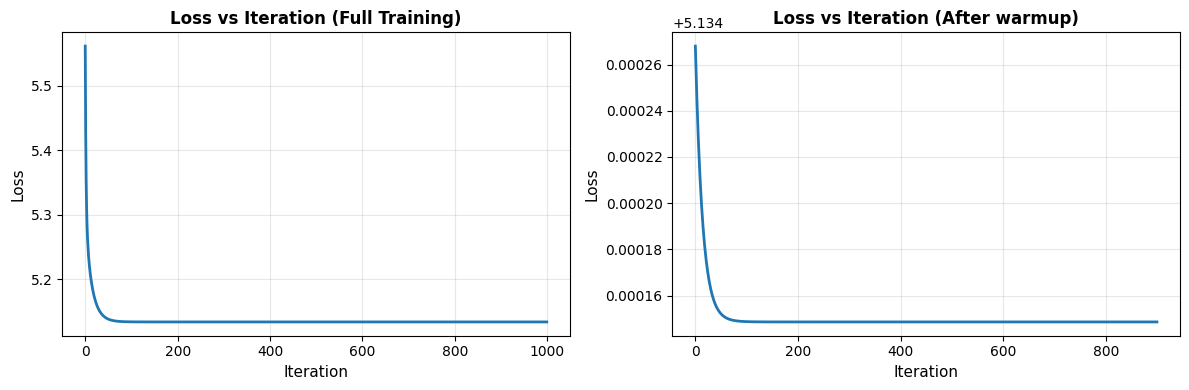


📊 Convergence Analysis:
  Initial loss:     5.5612
  Final loss:       5.1341
  Loss reduction:   0.4271
  Reduction %:      7.7%

✅ Model has converged (loss stabilized)


In [15]:
# Plot how loss decreased during training
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(my_losses, linewidth=2)
plt.xlabel('Iteration', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.title('Loss vs Iteration (Full Training)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(my_losses[100:], linewidth=2)  # Skip first 100 to see detail
plt.xlabel('Iteration', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.title('Loss vs Iteration (After warmup)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Convergence Analysis:")
print(f"  Initial loss:     {my_losses[0]:.4f}")
print(f"  Final loss:       {my_losses[-1]:.4f}")
print(f"  Loss reduction:   {my_losses[0] - my_losses[-1]:.4f}")
print(f"  Reduction %:      {100*(my_losses[0] - my_losses[-1])/my_losses[0]:.1f}%")

# Check if converged
last_100_change = abs(my_losses[-1] - my_losses[-100])
if last_100_change < 0.001:
    print("\n✅ Model has converged (loss stabilized)")
else:
    print(f"\n⚠️ Model may not have fully converged (change in last 100 iters: {last_100_change:.4f})")
    print("   Try increasing n_iterations or learning_rate")

**Good convergence looks like:**
- Loss decreases rapidly at first
- Then flattens out (reaches minimum)
- No oscillations or increases

**If you see oscillations**: Learning rate is too high

**If loss is still decreasing at the end**: Need more iterations

### Task 4.3: Compare with sklearn's Ridge

In [16]:
# Train sklearn's Ridge for comparison
sklearn_ridge = Ridge(alpha=1.0)
sklearn_ridge.fit(X_train_poly5_scaled, y_train)  # SOLUTION: use scaled training data

# Compare coefficients
print("\n" + "="*80)
print("COEFFICIENT COMPARISON: Our Ridge vs sklearn Ridge")
print("="*80)
print(f"{'Feature':<15} {'Our Ridge':>20} {'sklearn Ridge':>20} {'Difference':>15}")
print("-"*80)

for i in range(min(10, len(my_weights))):  # Show first 10 features
    diff = abs(my_weights[i] - sklearn_ridge.coef_[i])
    print(f"Feature {i:<8} {my_weights[i]:>20.6f} {sklearn_ridge.coef_[i]:>20.6f} {diff:>15.6f}")

print("="*80)

# Calculate R² on test set
my_predictions = X_test_poly5_scaled @ my_weights
my_r2 = r2_score(y_test, my_predictions)

sklearn_r2 = sklearn_ridge.score(X_test_poly5_scaled, y_test)

print(f"\n📊 Performance Comparison:")
print(f"  Our Ridge Test R²:    {my_r2:.6f}")
print(f"  sklearn Ridge Test R²: {sklearn_r2:.6f}")
print(f"  Difference:            {abs(my_r2 - sklearn_r2):.6f}")

# Calculate coefficient correlation
coef_correlation = np.corrcoef(my_weights, sklearn_ridge.coef_)[0, 1]
print(f"\n  Coefficient correlation: {coef_correlation:.6f}")

if abs(my_r2 - sklearn_r2) < 0.01:
    print("\n✅ Excellent! Our implementation matches sklearn very closely.")
elif abs(my_r2 - sklearn_r2) < 0.05:
    print("\n✅ Good! Our implementation is reasonably close to sklearn.")
    print("   Small differences are expected due to different optimization methods.")
else:
    print("\n⚠️ Significant difference. Possible issues:")
    print("   - May need more iterations")
    print("   - May need to adjust learning rate")
    print("   - sklearn uses closed-form solution (more accurate)")


COEFFICIENT COMPARISON: Our Ridge vs sklearn Ridge
Feature                    Our Ridge        sklearn Ridge      Difference
--------------------------------------------------------------------------------
Feature 0                    0.238153             0.459202        0.221049
Feature 1                    0.004949            -0.072146        0.077095
Feature 2                    0.146995             0.567584        0.420589
Feature 3                    0.132364             0.419488        0.287124
Feature 4                   -0.000332            -0.023298        0.022966
Feature 5                    0.060021             0.011461        0.048560
Feature 6                    0.058752            -0.438179        0.496930
Feature 7                    0.062990             0.463528        0.400538
Feature 8                   -0.005940            -0.025739        0.019799
Feature 9                    0.003634            -0.214933        0.218567

📊 Performance Comparison:
  Our Ridge Test

**Why might there be small differences?**
1. sklearn uses a closed-form solution (direct matrix inversion) - mathematically exact
2. Our gradient descent is iterative - approximate solution
3. Gradient descent might not have fully converged

**But both should give similar results!** If R² is close (within 0.01-0.05), you've implemented it correctly.

### Task 4.4: Experiment with Learning Rate

Testing different learning rates...

Learning rate = 0.001:
  Final loss: 5.1343
  Test R²:    -2.1337

Learning rate = 0.005:
  Final loss: 5.1341
  Test R²:    -2.1283

Learning rate = 0.01:
  Final loss: 5.1341
  Test R²:    -2.1283



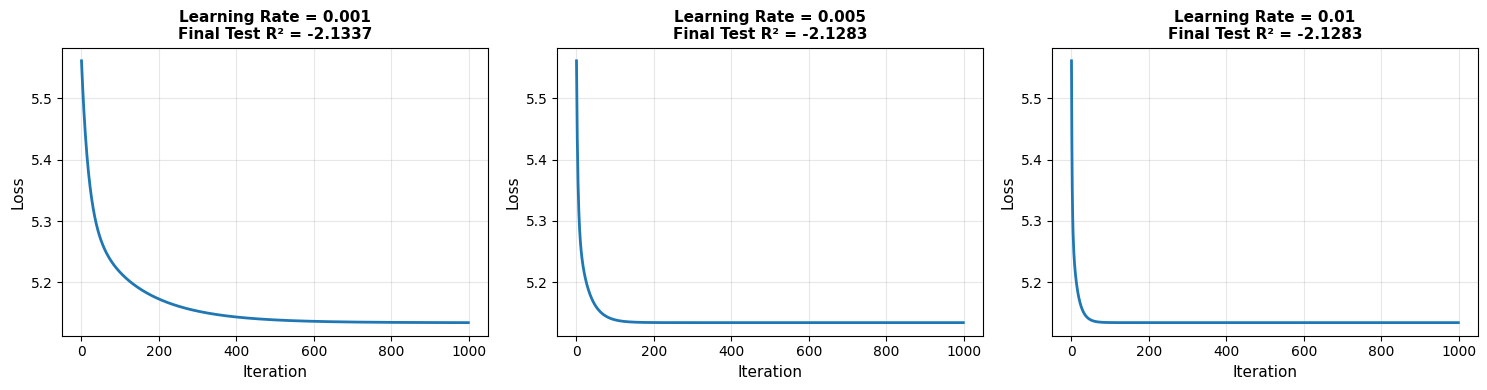


💡 Key Insights:
• Small learning rate (0.001): Slow but steady convergence
• Medium learning rate (0.005): Good balance - faster and stable
• Larger tested rate (0.01): Fastest stable convergence here

A much larger rate (for example, 0.1) can make the loss diverge, so it is not run in the standard solution.


In [17]:
# Test different learning rates
learning_rates = [0.001, 0.005, 0.01]

print("Testing different learning rates...\n")

plt.figure(figsize=(15, 4))

for i, lr in enumerate(learning_rates):
    print(f"Learning rate = {lr}:")
    
    weights, losses = ridge_gradient_descent(
        X_train_poly5_scaled, 
        y_train, 
        alpha=1.0,
        learning_rate=lr,
        n_iterations=1000
    )
    
    # Calculate performance
    predictions = X_test_poly5_scaled @ weights
    r2 = r2_score(y_test, predictions)
    
    print(f"  Final loss: {losses[-1]:.4f}")
    print(f"  Test R²:    {r2:.4f}")
    print()
    
    # Plot
    plt.subplot(1, 3, i+1)
    plt.plot(losses, linewidth=2)
    plt.xlabel('Iteration', fontsize=11)
    plt.ylabel('Loss', fontsize=11)
    plt.title(f'Learning Rate = {lr}\nFinal Test R² = {r2:.4f}', 
              fontsize=11, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Add convergence indicator
    if losses[-1] < losses[0] * 0.1:  # Loss reduced by 90%+
        plt.text(0.5, 0.95, '✅ Converged', 
                transform=plt.gca().transAxes,
                ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n💡 Key Insights:")
print("• Small learning rate (0.001): Slow but steady convergence")
print("• Medium learning rate (0.005): Good balance - faster and stable")
print("• Larger tested rate (0.01): Fastest stable convergence here")
print("\nA much larger rate (for example, 0.1) can make the loss diverge, so it is not run in the standard solution.")

**Learning rate is crucial:**
- **Too small**: Takes forever to converge (need many more iterations)
- **Too large**: Overshoots the minimum, loss oscillates or diverges
- **Just right**: Converges quickly and smoothly

**For this problem**: 0.01 is usually a good choice

### Task 4.5: Understanding the Regularization Effect

Training Ridge with different alpha values...

Alpha = 0.0:
  Test R²: -1.9725

Alpha = 0.1:
  Test R²: -1.9838

Alpha = 1.0:
  Test R²: -2.1283

Alpha = 10.0:
  Test R²: -2.4690



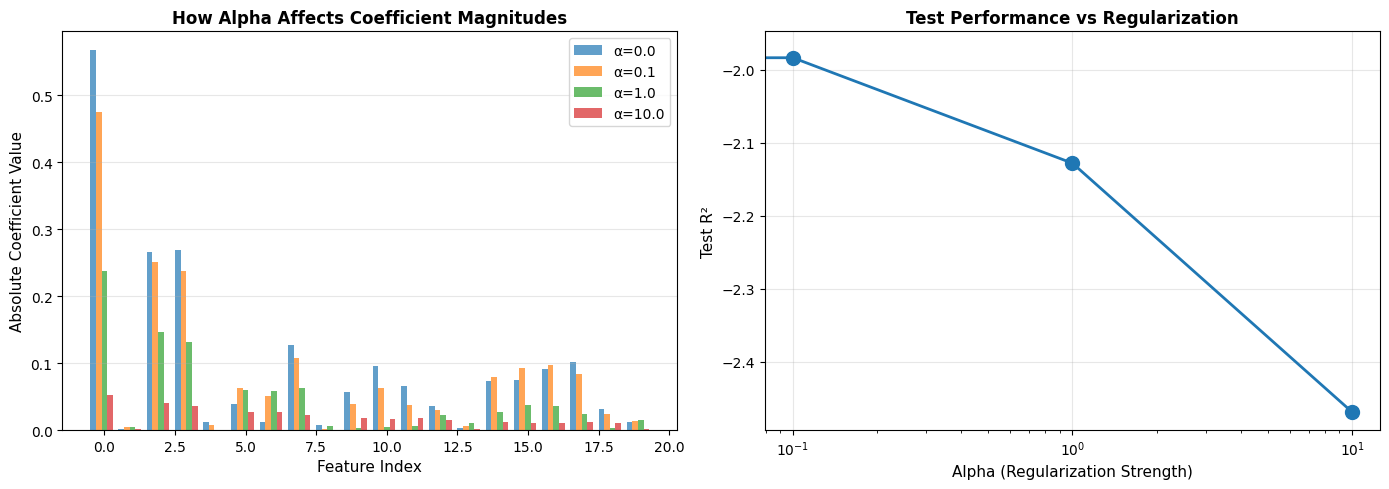


COEFFICIENT MAGNITUDE SUMMARY
Alpha           Max |coef|     Mean |coef|      Sum(coef²)         Test R²
--------------------------------------------------------------------------------
0.0                 0.5674          0.0971          0.5317         -1.9725
0.1                 0.4758          0.0883          0.4042         -1.9838
1.0                 0.2382          0.0451          0.1120         -2.1283
10.0                0.0531          0.0167          0.0095         -2.4690

💡 Key Observations:
1. As alpha increases, coefficient magnitudes DECREASE
2. Alpha=0 (no regularization) has the largest coefficients
3. Larger alpha = stronger regularization = smaller weights
4. There's an optimal alpha that balances fit vs simplicity

This is WHY Ridge is called 'weight decay' - it literally decays the weights!


In [18]:
# Train with different alpha values and track weight magnitudes
alphas_test = [0.0, 0.1, 1.0, 10.0]
final_weights = []
final_r2_scores = []

print("Training Ridge with different alpha values...\n")

for alpha in alphas_test:
    print(f"Alpha = {alpha}:")
    
    weights, losses = ridge_gradient_descent(
        X_train_poly5_scaled, 
        y_train, 
        alpha=alpha,
        learning_rate=0.01,
        n_iterations=1000
    )
    final_weights.append(weights)
    
    # Calculate R²
    predictions = X_test_poly5_scaled @ weights
    r2 = r2_score(y_test, predictions)
    final_r2_scores.append(r2)
    
    print(f"  Test R²: {r2:.4f}")
    print()

# Plot coefficient magnitudes
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
x = np.arange(len(final_weights[0]))
width = 0.2

for i, alpha in enumerate(alphas_test):
    offset = (i - len(alphas_test)/2) * width
    plt.bar(x + offset, np.abs(final_weights[i]), width, 
            label=f'α={alpha}', alpha=0.7)

plt.xlabel('Feature Index', fontsize=11)
plt.ylabel('Absolute Coefficient Value', fontsize=11)
plt.title('How Alpha Affects Coefficient Magnitudes', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
plt.plot(alphas_test, final_r2_scores, 'o-', linewidth=2, markersize=10)
plt.xlabel('Alpha (Regularization Strength)', fontsize=11)
plt.ylabel('Test R²', fontsize=11)
plt.title('Test Performance vs Regularization', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xscale('log')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("COEFFICIENT MAGNITUDE SUMMARY")
print("="*80)
print(f"{'Alpha':<10} {'Max |coef|':>15} {'Mean |coef|':>15} {'Sum(coef²)':>15} {'Test R²':>15}")
print("-"*80)

for i, alpha in enumerate(alphas_test):
    max_coef = np.max(np.abs(final_weights[i]))
    mean_coef = np.mean(np.abs(final_weights[i]))
    sum_sq = np.sum(final_weights[i] ** 2)
    print(f"{alpha:<10.1f} {max_coef:>15.4f} {mean_coef:>15.4f} {sum_sq:>15.4f} {final_r2_scores[i]:>15.4f}")

print("="*80)

print("\n💡 Key Observations:")
print("1. As alpha increases, coefficient magnitudes DECREASE")
print("2. Alpha=0 (no regularization) has the largest coefficients")
print("3. Larger alpha = stronger regularization = smaller weights")
print("4. There's an optimal alpha that balances fit vs simplicity")
print("\nThis is WHY Ridge is called 'weight decay' - it literally decays the weights!")

**Understanding the regularization term:**

The gradient has two parts:
1. **MSE gradient**: Pushes weights to fit the data
2. **Regularization gradient**: Pulls weights toward zero

Alpha controls the balance:
- **α = 0**: No penalty, weights can be large (overfitting)
- **α small**: Light penalty, weights shrink a bit
- **α large**: Heavy penalty, weights shrink a lot (underfitting)

**The magic**: At the right alpha, we get the best test performance!

### Optional Challenge: Implement Lasso

Training Lasso implementation...

Lasso Results:
  Zero coefficients:     19 out of 20
  Non-zero coefficients: 1
  Sparsity:              95.0%

  Test R²: -2.8520

Comparison with sklearn Lasso:
  Our Lasso R²:     -2.8520
  sklearn Lasso R²: -0.0016
  Difference:       2.8503


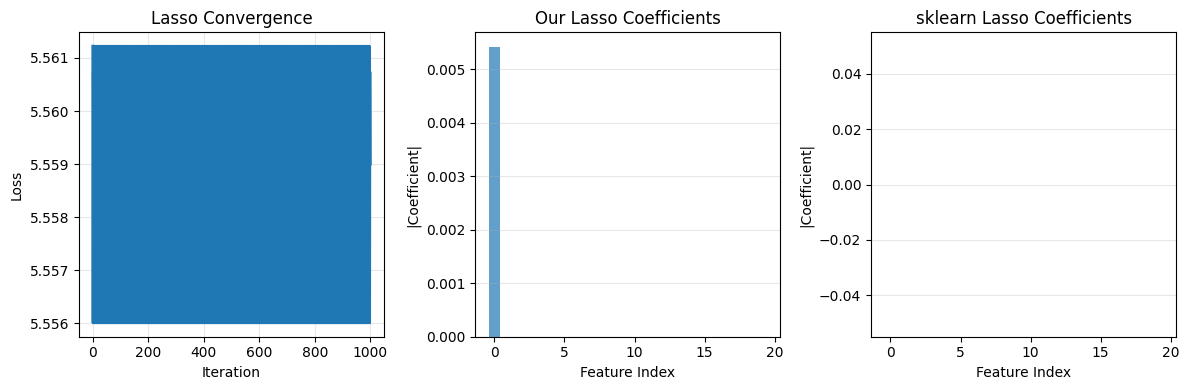


💡 Lasso vs Ridge:
• Ridge: Shrinks coefficients smoothly (none become exactly zero)
• Lasso: Creates sparsity (many coefficients become exactly zero)
• Lasso performs automatic feature selection!

This is due to the L1 penalty having a 'corner' at zero.


In [19]:
def lasso_gradient_descent(X, y, alpha=1.0, learning_rate=0.01, n_iterations=1000):
    """
    Implement Lasso regression using gradient descent with soft thresholding.
    
    The key difference from Ridge: uses |w| instead of w²
    Gradient uses sign(w) instead of w
    """
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    losses = []
    
    for iteration in range(n_iterations):
        # Predictions
        y_pred = X @ weights
        error = y_pred - y
        
        # Loss calculation
        mse = np.mean(error ** 2)
        reg_term = alpha * np.sum(np.abs(weights))  # L1 penalty
        total_loss = mse + reg_term
        losses.append(total_loss)
        
        # Gradient calculation
        mse_gradient = (2 / n_samples) * (X.T @ error)
        
        # Lasso regularization gradient: alpha * sign(w)
        # sign(w) = +1 if w>0, -1 if w<0, 0 if w=0
        reg_gradient = alpha * np.sign(weights)
        
        gradient = mse_gradient + reg_gradient
        
        # Update weights
        weights = weights - learning_rate * gradient
        
        # Soft thresholding (helps push small weights to exactly zero)
        # This is a key technique for Lasso to achieve sparsity
        threshold = learning_rate * alpha
        weights = np.sign(weights) * np.maximum(np.abs(weights) - threshold, 0)
    
    return weights, losses

# Test Lasso implementation
print("Training Lasso implementation...\n")

lasso_weights, lasso_losses = lasso_gradient_descent(
    X_train_poly5_scaled, 
    y_train, 
    alpha=1.0, 
    learning_rate=0.01, 
    n_iterations=1000
)

# Count zero coefficients
num_zero = np.sum(np.abs(lasso_weights) < 1e-10)
num_nonzero = np.sum(np.abs(lasso_weights) >= 1e-10)

print(f"Lasso Results:")
print(f"  Zero coefficients:     {num_zero} out of {len(lasso_weights)}")
print(f"  Non-zero coefficients: {num_nonzero}")
print(f"  Sparsity:              {100*num_zero/len(lasso_weights):.1f}%")

# Calculate R²
lasso_predictions = X_test_poly5_scaled @ lasso_weights
lasso_r2 = r2_score(y_test, lasso_predictions)
print(f"\n  Test R²: {lasso_r2:.4f}")

# Compare with sklearn
sklearn_lasso = Lasso(alpha=1.0, max_iter=10000)
sklearn_lasso.fit(X_train_poly5_scaled, y_train)
sklearn_lasso_r2 = sklearn_lasso.score(X_test_poly5_scaled, y_test)

print(f"\nComparison with sklearn Lasso:")
print(f"  Our Lasso R²:     {lasso_r2:.4f}")
print(f"  sklearn Lasso R²: {sklearn_lasso_r2:.4f}")
print(f"  Difference:       {abs(lasso_r2 - sklearn_lasso_r2):.4f}")

# Visualize sparsity
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(lasso_losses, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Lasso Convergence')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
x = np.arange(len(lasso_weights))
plt.bar(x, np.abs(lasso_weights), alpha=0.7, label='Our Lasso')
plt.xlabel('Feature Index')
plt.ylabel('|Coefficient|')
plt.title('Our Lasso Coefficients')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 3, 3)
plt.bar(x, np.abs(sklearn_lasso.coef_), alpha=0.7, label='sklearn Lasso', color='orange')
plt.xlabel('Feature Index')
plt.ylabel('|Coefficient|')
plt.title('sklearn Lasso Coefficients')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n💡 Lasso vs Ridge:")
print("• Ridge: Shrinks coefficients smoothly (none become exactly zero)")
print("• Lasso: Creates sparsity (many coefficients become exactly zero)")
print("• Lasso performs automatic feature selection!")
print("\nThis is due to the L1 penalty having a 'corner' at zero.")

**Why Lasso creates sparsity:**

The L1 penalty $|w|$ has a "sharp corner" at w=0. When the gradient descent update crosses zero, the soft thresholding step pushes small weights exactly to zero.

Ridge's L2 penalty $w²$ is smooth everywhere, so weights approach zero asymptotically but never reach it exactly.

**Geometric intuition**: In 2D, L1 constraint is a diamond, L2 constraint is a circle. The diamond has corners that align with the axes, making it more likely to have zeros.

---

## MPS439 Reflection Questions - Answers

**1. Why does Ridge lead to coefficient shrinkage?**

Answer: The regularization term $\lambda \sum w_j^2$ adds $2\lambda w_j$ to each coefficient's gradient. This creates a force that pulls every weight toward zero during gradient descent. The larger the weight, the stronger this pull. At equilibrium, the MSE gradient (fit data) balances the regularization gradient (shrink weights), resulting in smaller coefficients than unregularized regression.

**2. What's the role of the learning rate in gradient descent?**

Answer: The learning rate controls how far we move in the direction indicated by the gradient. Too small: slow convergence, needs many iterations. Too large: overshoots the minimum, may oscillate or diverge. The optimal learning rate balances speed and stability. For this problem, 0.01 works well - fast enough to converge in ~1000 iterations, but stable.

**3. How would you explain the difference between Ridge and Lasso's regularization?**

Answer: Both penalize coefficient magnitude, but differently. Ridge uses $\lambda \sum w_j^2$ (squared penalty) which creates smooth shrinkage - all coefficients get smaller but never exactly zero. Lasso uses $\lambda \sum |w_j|$ (absolute penalty) which creates sparsity - many coefficients become exactly zero. This difference comes from the shape of the penalty: L2 is smooth everywhere, L1 has a sharp corner at zero. Practically, Ridge is better when all features matter (even weakly), Lasso is better for feature selection when many features are irrelevant.

**4. For your assignment, which implementation option interests you most?**

Answer: (This is personal - here's an example)

Option A (Ridge implementation) interests me most because I want to deeply understand the optimization process. Implementing gradient descent from scratch reveals how regularization actually works at the algorithmic level, not just conceptually. I'm curious about how different hyperparameters (learning rate, alpha) affect convergence and how the regularization term influences the gradient at each step. This will help me understand why sklearn makes certain design choices and prepare me for implementing more advanced optimization algorithms in the future.

---

## Summary: What We Learned

### Core Concepts (All Students)
✅ **Polynomial Features**: Transform linear models to fit non-linear patterns

✅ **Overfitting**: When models memorize training noise instead of learning patterns

✅ **Ridge Regression**: Penalizes sum of squared coefficients (L2)

✅ **Lasso Regression**: Penalizes sum of absolute coefficients (L1), creates sparsity

✅ **Scaling**: Always use StandardScaler before regularized models

✅ **Cross-Validation**: Find optimal hyperparameters without touching test data

### Advanced Concepts (MPS439)
✅ **Gradient Descent**: Iterative optimization algorithm

✅ **Learning Rate**: Controls step size, crucial for convergence

✅ **Regularization Mechanics**: How penalty terms affect gradients

✅ **Ridge Implementation**: Complete working implementation from scratch

✅ **Lasso Implementation**: Understanding soft thresholding and sparsity

---

## Skills for Assignment 1

You now have everything needed for the assignment:
- ✅ Feature engineering (polynomial features, custom features)
- ✅ Ridge and Lasso regression with sklearn
- ✅ Cross-validation for hyperparameter tuning
- ✅ Model comparison and evaluation
- ✅ (MPS439) Implementation from scratch for Options A/B

**Good luck with your assignment!** 🎉